# Project 8 — HR Employee Attrition Analytics

**Objective:** Analyze employee attrition, identify the main factors associated with employees leaving, and produce business-ready HR KPIs and insights.

**Dataset:** `WA_Fn-UseC_-HR-Employee-Attrition.csv`

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

**Workflow:** Data loading → data quality → cleaning → KPI analysis → EDA → attrition-driver analysis → business insights → export cleaned data.


In [1]:
# 1. Import libraries
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

FILE = Path("WA_Fn-UseC_-HR-Employee-Attrition.csv")
if not FILE.exists():
    FILE = Path("WA_Fn-UseC_-HR-Employee-Attrition.csv")

assert FILE.exists(), f"Dataset not found: {FILE}"
df = pd.read_csv(FILE)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [2]:
# 2. Data structure and quality check
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

quality = pd.DataFrame({
    "missing_values": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique()
}).sort_values("missing_values", ascending=False)

print("\nData quality summary:")
display(quality)

print("Duplicate rows:", df.duplicated().sum())


Rows: 1470
Columns: 35

Data types:


,dtype
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64



Data quality summary:


,missing_values,missing_pct,unique_values
Age,0,0.0,43
Attrition,0,0.0,2
BusinessTravel,0,0.0,3
DailyRate,0,0.0,886
Department,0,0.0,3
DistanceFromHome,0,0.0,29
Education,0,0.0,5
EducationField,0,0.0,6
EmployeeCount,0,0.0,1
EmployeeNumber,0,0.0,1470


Duplicate rows: 0


In [3]:
# 3. Basic cleaning and analytical columns
data = df.copy()

# Remove exact duplicate rows if present
data = data.drop_duplicates().copy()

# Standardize text columns
text_cols = data.select_dtypes(include="object").columns
for col in text_cols:
    data[col] = data[col].astype(str).str.strip()

# Binary analytical fields
data["Attrition_Flag"] = data["Attrition"].map({"Yes": 1, "No": 0})
data["OverTime_Flag"] = data["OverTime"].map({"Yes": 1, "No": 0})

# Useful business bands
data["Age_Group"] = pd.cut(
    data["Age"],
    bins=[0, 25, 35, 45, 55, np.inf],
    labels=["<=25", "26-35", "36-45", "46-55", "56+"]
)

data["Income_Band"] = pd.qcut(
    data["MonthlyIncome"],
    q=4,
    labels=["Low", "Lower-Mid", "Upper-Mid", "High"],
    duplicates="drop"
)

data["Tenure_Band"] = pd.cut(
    data["YearsAtCompany"],
    bins=[-1, 1, 3, 5, 10, np.inf],
    labels=["0-1", "2-3", "4-5", "6-10", "11+"]
)

print("Cleaned shape:", data.shape)
display(data.head())


Cleaned shape: (1470, 40)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Flag,OverTime_Flag,Age_Group,Income_Band,Tenure_Band
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5,1,1,36-45,Upper-Mid,6-10
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7,0,0,46-55,Upper-Mid,6-10
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0,1,1,36-45,Low,0-1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0,0,1,26-35,Low,6-10
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2,0,0,26-35,Lower-Mid,2-3


In [4]:
# 4. Executive HR KPIs
total_employees = len(data)
attrition_count = int(data["Attrition_Flag"].sum())
attrition_rate = data["Attrition_Flag"].mean() * 100
avg_age = data["Age"].mean()
avg_income = data["MonthlyIncome"].mean()
avg_tenure = data["YearsAtCompany"].mean()
overtime_rate = data["OverTime_Flag"].mean() * 100

kpis = pd.DataFrame({
    "KPI": [
        "Total Employees", "Employees Left", "Attrition Rate",
        "Average Age", "Average Monthly Income", "Average Years at Company",
        "Overtime Rate"
    ],
    "Value": [
        total_employees, attrition_count, round(attrition_rate, 2),
        round(avg_age, 2), round(avg_income, 2), round(avg_tenure, 2),
        round(overtime_rate, 2)
    ]
})
display(kpis)


,KPI,Value
0,Total Employees,1470.00
1,Employees Left,237.00
2,Attrition Rate,16.12
3,Average Age,36.92
4,Average Monthly Income,6502.93
5,Average Years at Company,7.01
6,Overtime Rate,28.30


,Attrition,Employees,Percentage
0,No,1233,83.88
1,Yes,237,16.12


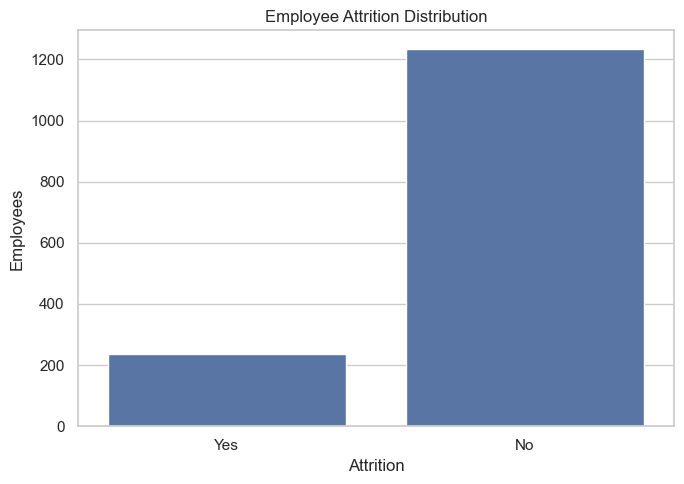

In [5]:
# 5. Attrition distribution
attrition_summary = (
    data["Attrition"]
    .value_counts()
    .rename_axis("Attrition")
    .reset_index(name="Employees")
)
attrition_summary["Percentage"] = (
    attrition_summary["Employees"] / total_employees * 100
).round(2)
display(attrition_summary)

plt.figure(figsize=(7,5))
sns.countplot(data=data, x="Attrition")
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Employees")
plt.tight_layout()
plt.show()


Attrition,No,Yes
Department,,
Human Resources,80.95,19.05
Research & Development,86.16,13.84
Sales,79.37,20.63


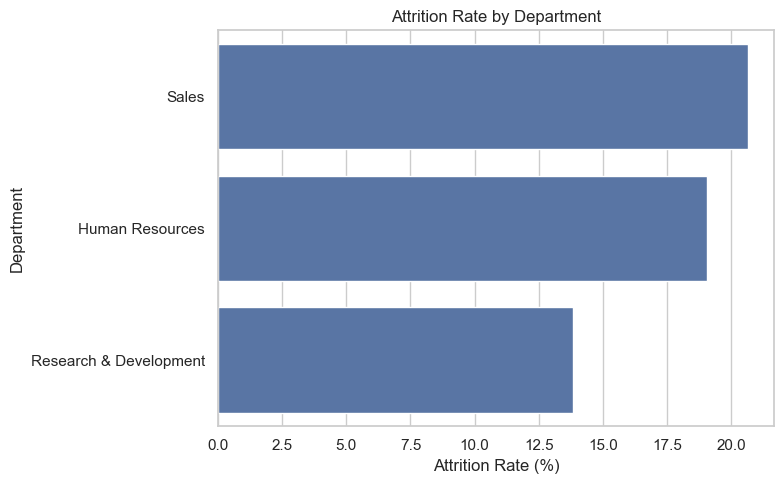

In [6]:
# 6. Attrition by department
dept = pd.crosstab(data["Department"], data["Attrition"], normalize="index") * 100
dept = dept.round(2)
display(dept)

dept_rate = data.groupby("Department")["Attrition_Flag"].mean().mul(100).sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=dept_rate.values, y=dept_rate.index)
plt.title("Attrition Rate by Department")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Department")
plt.tight_layout()
plt.show()


,Attrition Rate (%)
JobRole,
Sales Representative,39.76
Laboratory Technician,23.94
Human Resources,23.08
Sales Executive,17.48
Research Scientist,16.10
Manufacturing Director,6.90
Healthcare Representative,6.87
Manager,4.90
Research Director,2.50


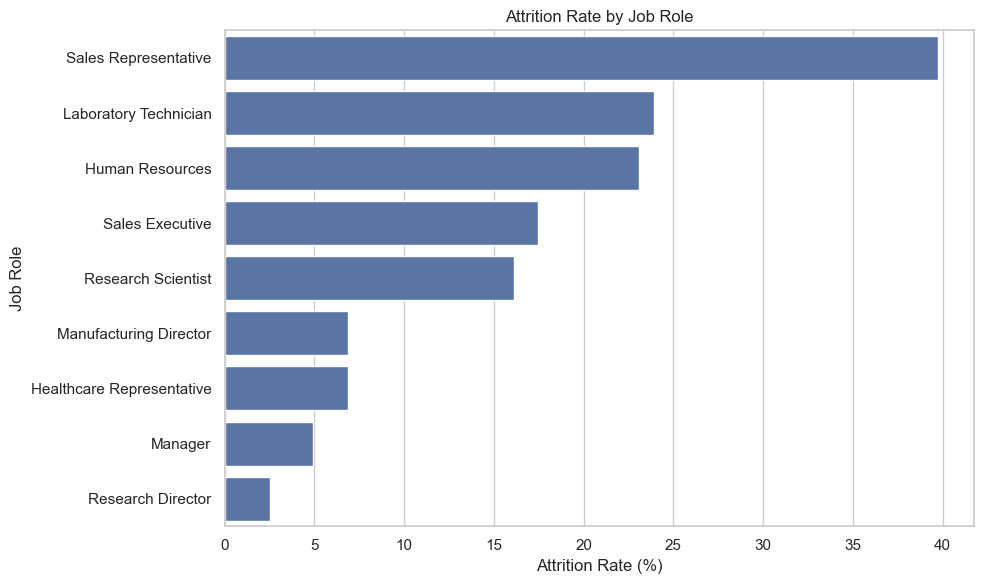

In [7]:
# 7. Attrition by job role
role_rate = (
    data.groupby("JobRole")["Attrition_Flag"]
    .mean().mul(100)
    .sort_values(ascending=False)
)
display(role_rate.round(2).to_frame("Attrition Rate (%)"))

plt.figure(figsize=(10,6))
sns.barplot(x=role_rate.values, y=role_rate.index)
plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")
plt.tight_layout()
plt.show()


,Employees,Employees_Left,Attrition_Rate
OverTime,,,
No,1054,110,10.44
Yes,416,127,30.53


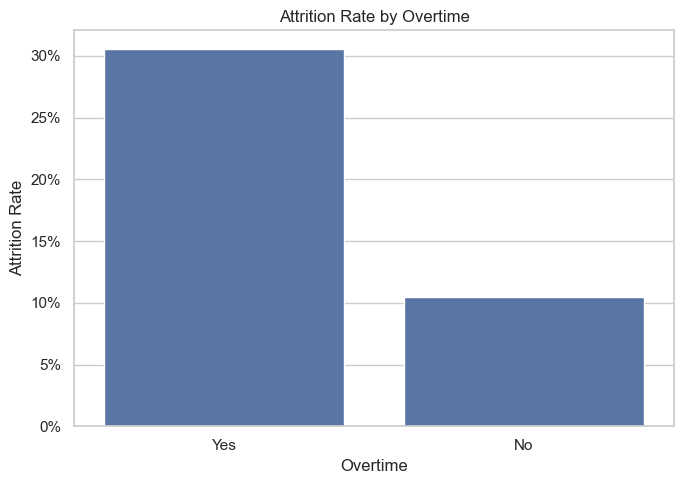

In [8]:
# 8. Overtime — one of the most important HR risk indicators
overtime_rate_table = (
    data.groupby("OverTime")["Attrition_Flag"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"count":"Employees", "sum":"Employees_Left", "mean":"Attrition_Rate"})
)
overtime_rate_table["Attrition_Rate"] = (overtime_rate_table["Attrition_Rate"] * 100).round(2)
display(overtime_rate_table)

plt.figure(figsize=(7,5))
sns.barplot(data=data, x="OverTime", y="Attrition_Flag", estimator=np.mean, errorbar=None)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))
plt.title("Attrition Rate by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate")
plt.tight_layout()
plt.show()


,Attrition Rate (%)
Age_Group,
<=25,35.77
26-35,19.14
36-45,9.19
46-55,11.50
56+,17.02


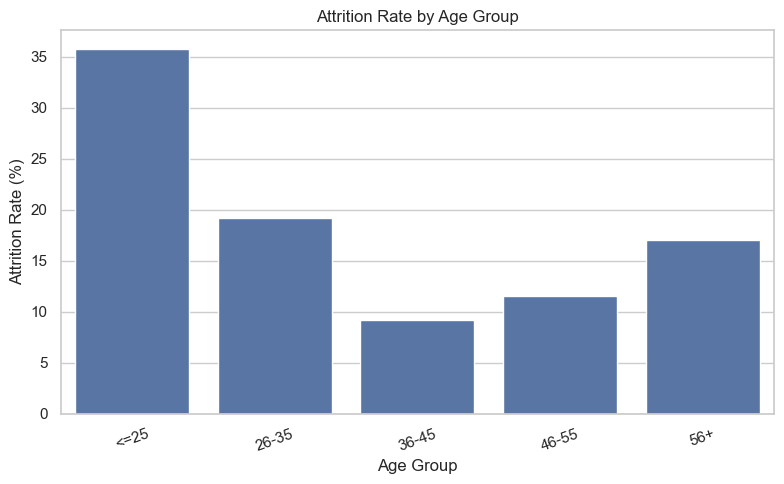

In [9]:
# 9. Attrition by age group
age_group_rate = (
    data.groupby("Age_Group", observed=True)["Attrition_Flag"]
    .mean().mul(100).round(2)
)
display(age_group_rate.to_frame("Attrition Rate (%)"))

plt.figure(figsize=(8,5))
sns.barplot(x=age_group_rate.index.astype(str), y=age_group_rate.values)
plt.title("Attrition Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [10]:
# 10. Attrition by marital status and gender
for col in ["MaritalStatus", "Gender", "BusinessTravel", "JobLevel"]:
    result = data.groupby(col)["Attrition_Flag"].mean().mul(100).sort_values(ascending=False).round(2)
    print(f"\n{col}")
    display(result.to_frame("Attrition Rate (%)"))



MaritalStatus


,Attrition Rate (%)
MaritalStatus,
Single,25.53
Married,12.48
Divorced,10.09



Gender


,Attrition Rate (%)
Gender,
Male,17.01
Female,14.80



BusinessTravel


,Attrition Rate (%)
BusinessTravel,
Travel_Frequently,24.91
Travel_Rarely,14.96
Non-Travel,8.00



JobLevel


,Attrition Rate (%)
JobLevel,
1,26.34
3,14.68
2,9.74
5,7.25
4,4.72


In [11]:
# 11. Job satisfaction, environment satisfaction and work-life balance
factor_cols = [
    "JobSatisfaction", "EnvironmentSatisfaction",
    "RelationshipSatisfaction", "WorkLifeBalance",
    "JobInvolvement", "PerformanceRating"
]

factor_results = []
for col in factor_cols:
    temp = data.groupby(col)["Attrition_Flag"].agg(["count", "mean"]).reset_index()
    temp["Attrition_Rate"] = (temp["mean"] * 100).round(2)
    temp["Factor"] = col
    factor_results.append(temp[[ "Factor", col, "count", "Attrition_Rate" ]])

factor_analysis = pd.concat(factor_results, ignore_index=True)
display(factor_analysis)


,Factor,JobSatisfaction,count,Attrition_Rate,EnvironmentSatisfaction,RelationshipSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating
0,JobSatisfaction,1.0,289,22.84,NaN,NaN,NaN,NaN,NaN
1,JobSatisfaction,2.0,280,16.43,NaN,NaN,NaN,NaN,NaN
2,JobSatisfaction,3.0,442,16.52,NaN,NaN,NaN,NaN,NaN
3,JobSatisfaction,4.0,459,11.33,NaN,NaN,NaN,NaN,NaN
4,EnvironmentSatisfaction,NaN,284,25.35,1.0,NaN,NaN,NaN,NaN
5,EnvironmentSatisfaction,NaN,287,14.98,2.0,NaN,NaN,NaN,NaN
6,EnvironmentSatisfaction,NaN,453,13.69,3.0,NaN,NaN,NaN,NaN
7,EnvironmentSatisfaction,NaN,446,13.45,4.0,NaN,NaN,NaN,NaN
8,RelationshipSatisfaction,NaN,276,20.65,NaN,1.0,NaN,NaN,NaN
9,RelationshipSatisfaction,NaN,303,14.85,NaN,2.0,NaN,NaN,NaN


,Age,MonthlyIncome,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager,YearsSinceLastPromotion
Attrition,,,,,,,
No,37.56,6832.74,11.86,7.37,4.48,4.37,2.23
Yes,33.61,4787.09,8.24,5.13,2.90,2.85,1.95


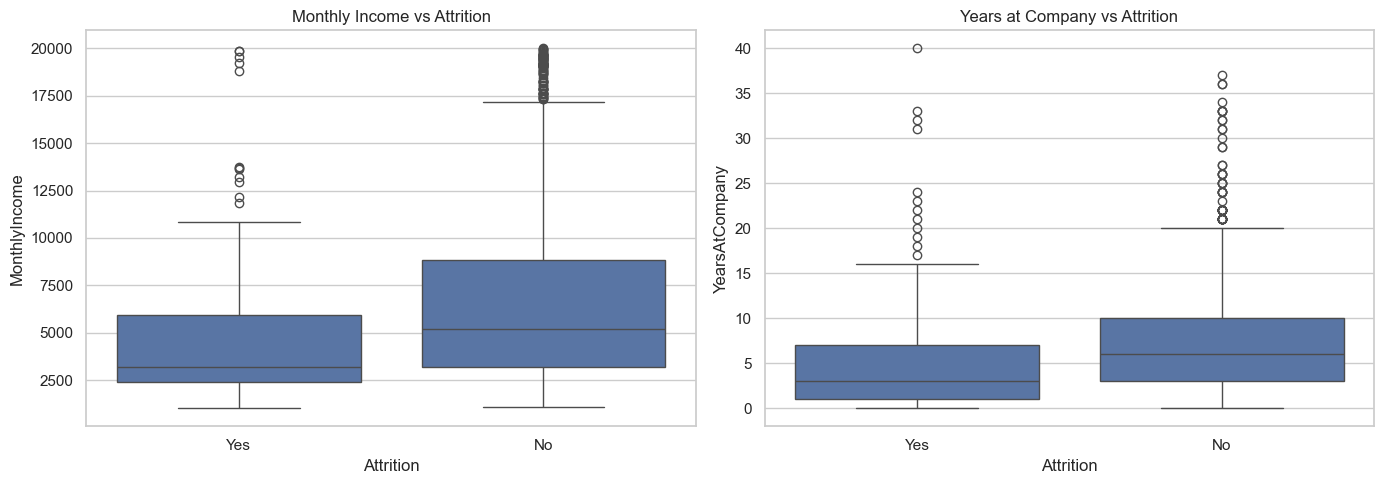

In [12]:
# 12. Income, tenure and total working years
numeric_compare = data.groupby("Attrition")[
    ["Age", "MonthlyIncome", "TotalWorkingYears", "YearsAtCompany",
     "YearsInCurrentRole", "YearsWithCurrManager", "YearsSinceLastPromotion"]
].mean().round(2)

display(numeric_compare)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(data=data, x="Attrition", y="MonthlyIncome", ax=axes[0])
axes[0].set_title("Monthly Income vs Attrition")

sns.boxplot(data=data, x="Attrition", y="YearsAtCompany", ax=axes[1])
axes[1].set_title("Years at Company vs Attrition")

plt.tight_layout()
plt.show()


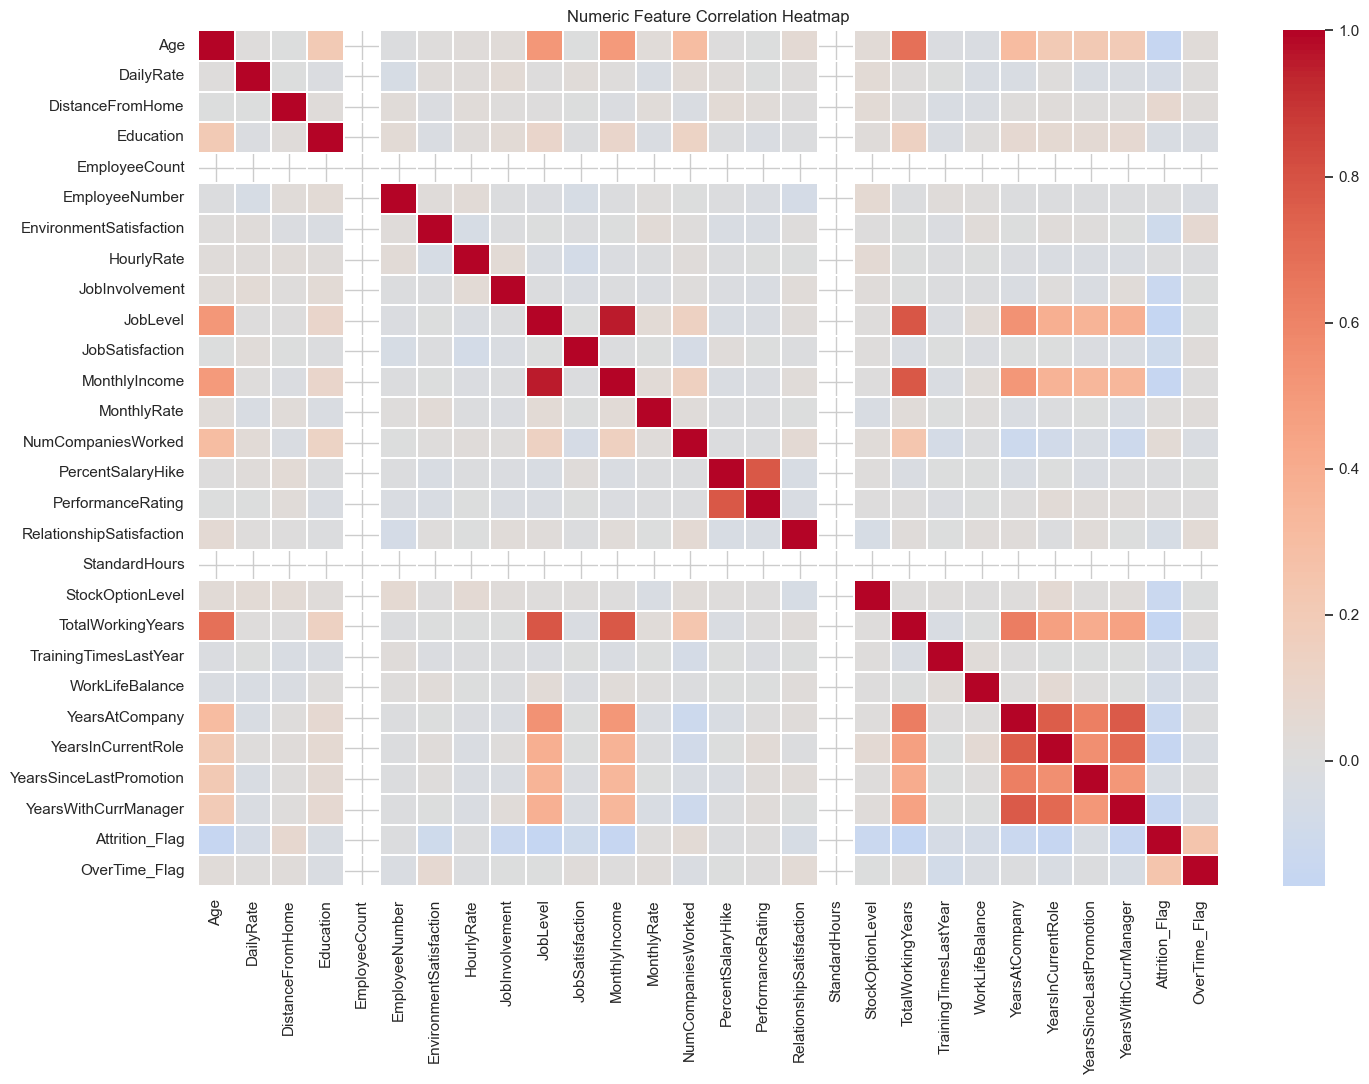

,Correlation with Attrition
TotalWorkingYears,-0.171063
JobLevel,-0.169105
YearsInCurrentRole,-0.160545
MonthlyIncome,-0.159840
Age,-0.159205
YearsWithCurrManager,-0.156199
StockOptionLevel,-0.137145
YearsAtCompany,-0.134392
HourlyRate,-0.006846
PerformanceRating,0.002889


In [13]:
# 13. Correlation analysis for numeric variables
numeric_data = data.select_dtypes(include=np.number)
corr = numeric_data.corr(numeric_only=True)

plt.figure(figsize=(15,11))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Numeric Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

attrition_corr = corr["Attrition_Flag"].drop("Attrition_Flag").sort_values()
display(pd.concat([attrition_corr.head(8), attrition_corr.tail(8)]).to_frame("Correlation with Attrition"))


In [14]:
# 14. High-risk segment analysis
risk = (
    data.groupby(["OverTime", "JobLevel", "MaritalStatus"])["Attrition_Flag"]
    .agg(["count", "sum", "mean"])
    .reset_index()
    .rename(columns={"count":"Employees", "sum":"Employees_Left", "mean":"Attrition_Rate"})
)

risk["Attrition_Rate"] = (risk["Attrition_Rate"] * 100).round(2)
risk = risk.sort_values(["Attrition_Rate", "Employees"], ascending=[False, False])

print("Top segments by attrition rate (minimum 10 employees):")
display(risk[risk["Employees"] >= 10].head(15))


Top segments by attrition rate (minimum 10 employees):


,OverTime,JobLevel,MaritalStatus,Employees,Employees_Left,Attrition_Rate
17,Yes,1,Single,59,40,67.80
15,Yes,1,Divorced,34,15,44.12
16,Yes,1,Married,63,27,42.86
23,Yes,3,Single,17,7,41.18
20,Yes,2,Single,41,13,31.71
2,No,1,Single,143,38,26.57
7,No,3,Married,72,13,18.06
19,Yes,2,Married,71,11,15.49
22,Yes,3,Married,27,4,14.81
5,No,2,Single,120,13,10.83


In [15]:
# 15. Business-ready summary tables
department_summary = (
    data.groupby("Department")
    .agg(
        Employees=("EmployeeNumber", "count"),
        Employees_Left=("Attrition_Flag", "sum"),
        Attrition_Rate=("Attrition_Flag", "mean"),
        Avg_Income=("MonthlyIncome", "mean"),
        Avg_Tenure=("YearsAtCompany", "mean")
    )
    .reset_index()
)
department_summary["Attrition_Rate"] = (department_summary["Attrition_Rate"] * 100).round(2)
department_summary["Avg_Income"] = department_summary["Avg_Income"].round(2)
department_summary["Avg_Tenure"] = department_summary["Avg_Tenure"].round(2)

display(department_summary)

jobrole_summary = (
    data.groupby("JobRole")
    .agg(
        Employees=("EmployeeNumber", "count"),
        Employees_Left=("Attrition_Flag", "sum"),
        Attrition_Rate=("Attrition_Flag", "mean"),
        Avg_Income=("MonthlyIncome", "mean")
    )
    .reset_index()
)
jobrole_summary["Attrition_Rate"] = (jobrole_summary["Attrition_Rate"] * 100).round(2)
jobrole_summary["Avg_Income"] = jobrole_summary["Avg_Income"].round(2)
display(jobrole_summary.sort_values("Attrition_Rate", ascending=False))


,Department,Employees,Employees_Left,Attrition_Rate,Avg_Income,Avg_Tenure
0,Human Resources,63,12,19.05,6654.51,7.24
1,Research & Development,961,133,13.84,6281.25,6.86
2,Sales,446,92,20.63,6959.17,7.28


,JobRole,Employees,Employees_Left,Attrition_Rate,Avg_Income
8,Sales Representative,83,33,39.76,2626.00
2,Laboratory Technician,259,62,23.94,3237.17
1,Human Resources,52,12,23.08,4235.75
7,Sales Executive,326,57,17.48,6924.28
6,Research Scientist,292,47,16.10,3239.97
4,Manufacturing Director,145,10,6.90,7295.14
0,Healthcare Representative,131,9,6.87,7528.76
3,Manager,102,5,4.90,17181.68
5,Research Director,80,2,2.50,16033.55


In [16]:
# 16. Automated business insights
highest_dept = department_summary.loc[department_summary["Attrition_Rate"].idxmax()]
highest_role = jobrole_summary.loc[jobrole_summary["Attrition_Rate"].idxmax()]
ot_rates = data.groupby("OverTime")["Attrition_Flag"].mean() * 100
highest_ot = ot_rates.idxmax()

print("KEY BUSINESS INSIGHTS")
print("-" * 60)
print(f"Overall attrition rate: {attrition_rate:.2f}%")
print(f"Highest department attrition: {highest_dept['Department']} ({highest_dept['Attrition_Rate']:.2f}%)")
print(f"Highest job-role attrition: {highest_role['JobRole']} ({highest_role['Attrition_Rate']:.2f}%)")
print(f"Highest overtime attrition segment: {highest_ot} ({ot_rates[highest_ot]:.2f}%)")
print(f"Average monthly income: {avg_income:,.2f}")
print(f"Average tenure: {avg_tenure:.2f} years")

print("\nRecommended HR actions:")
print("1. Prioritize retention plans for high-attrition job roles and departments.")
print("2. Review workload, overtime and scheduling for employees with overtime exposure.")
print("3. Strengthen career progression and manager support for short-tenure employees.")
print("4. Review compensation and promotion patterns in high-attrition segments.")
print("5. Track these KPIs monthly in Power BI or an HR management dashboard.")


KEY BUSINESS INSIGHTS
------------------------------------------------------------
Overall attrition rate: 16.12%
Highest department attrition: Sales (20.63%)
Highest job-role attrition: Sales Representative (39.76%)
Highest overtime attrition segment: Yes (30.53%)
Average monthly income: 6,502.93
Average tenure: 7.01 years

Recommended HR actions:
1. Prioritize retention plans for high-attrition job roles and departments.
2. Review workload, overtime and scheduling for employees with overtime exposure.
3. Strengthen career progression and manager support for short-tenure employees.
4. Review compensation and promotion patterns in high-attrition segments.
5. Track these KPIs monthly in Power BI or an HR management dashboard.


In [17]:
# 17. Export cleaned dataset and summary tables
data.to_csv("project8_hr_employee_attrition_cleaned.csv", index=False)
department_summary.to_csv("project8_department_summary.csv", index=False)
jobrole_summary.to_csv("project8_jobrole_summary.csv", index=False)
kpis.to_csv("project8_hr_kpis.csv", index=False)

print("Export complete.")
print("Files created:")
for f in [
    "project8_hr_employee_attrition_cleaned.csv",
    "project8_department_summary.csv",
    "project8_jobrole_summary.csv",
    "project8_hr_kpis.csv"
]:
    print(" -", f)


Export complete.
Files created:
 - project8_hr_employee_attrition_cleaned.csv
 - project8_department_summary.csv
 - project8_jobrole_summary.csv
 - project8_hr_kpis.csv


## Final Portfolio Deliverables

- **Python/Jupyter:** Complete HR attrition analysis and business insights.
- **SQL:** KPI queries, department/job-role analysis, overtime analysis, satisfaction analysis and retention segments.
- **Power BI:** Use the cleaned CSV for the final HR Attrition Dashboard.

### Suggested Power BI pages
1. **Executive HR Overview** — Total Employees, Employees Left, Attrition Rate, Average Income, Average Tenure.
2. **Attrition Drivers** — Overtime, Job Role, Department, Age Group, Business Travel.
3. **Employee & Retention Analysis** — Job Satisfaction, Environment Satisfaction, Work-Life Balance, Tenure and Income.
